# Actividad 2: Clasificación mediante árboles de decisión de Nestor Fernandez

En este notebook voy a realizar la práctica 2 utilizando árboles de decisión con `scikit-learn`. La idea es seguir lo que pide el enunciado: elegir una variable objetivo, discretizarla, estudiar las correlaciones, probar qué pasa si quito la variable más correlacionada y comparar los resultados finales del modelo.


In [2]:
# Importo las librerías que voy a utilizar en la práctica
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

# Cargo directamente el archivo del dataset
ruta_csv = Path('datos_act2.csv')

if not ruta_csv.exists():
    raise FileNotFoundError(
        "No encuentro el archivo 'datos_act2.csv'. "
        "Asegúrate de que está en la misma carpeta que el notebook."
    )

print("Archivo cargado:", ruta_csv)
df = pd.read_csv(ruta_csv)
df.head()


Archivo cargado: datos_act2.csv


,ANO,MES,DIA,MUNICIPIO,ESTACION,SO2,CO,NO,NO2,PM2.5,PM10,NOx,O3,TOL,BEN,EBE
0,2021,1,1,79,4,5.0,0.2,2.0,10.0,NaN,NaN,12.0,NaN,NaN,NaN,NaN
1,2021,1,1,79,8,2.0,0.2,4.0,23.0,3.0,4.0,29.0,51.0,0.6,0.4,0.2
2,2021,1,1,79,11,NaN,NaN,3.0,17.0,NaN,NaN,21.0,NaN,0.2,0.2,0.1
3,2021,1,1,79,16,NaN,NaN,3.0,18.0,NaN,NaN,22.0,51.0,NaN,NaN,NaN
4,2021,1,1,79,17,NaN,NaN,3.0,13.0,NaN,NaN,18.0,65.0,NaN,NaN,NaN


## Exploración inicial del dataset

Primero cargo el fichero y reviso sus dimensiones, los tipos de datos y las variables que tenemos disponibles para trabajar.


In [3]:
# Reviso tamaño, tipos de datos y una primera descripción general
print('Dimensiones:', df.shape)
display(df.info())
display(df.describe(include='all').T)

Dimensiones: (7918, 16)
<class 'pandas.DataFrame'>
RangeIndex: 7918 entries, 0 to 7917
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ANO        7918 non-null   int64  
 1   MES        7918 non-null   int64  
 2   DIA        7918 non-null   int64  
 3   MUNICIPIO  7918 non-null   int64  
 4   ESTACION   7918 non-null   int64  
 5   SO2        1555 non-null   float64
 6   CO         1583 non-null   float64
 7   NO         7901 non-null   float64
 8   NO2        7901 non-null   float64
 9   PM2.5      2573 non-null   float64
 10  PM10       4197 non-null   float64
 11  NOx        7901 non-null   float64
 12  O3         4266 non-null   float64
 13  TOL        1907 non-null   float64
 14  BEN        1885 non-null   float64
 15  EBE        1885 non-null   float64
dtypes: float64(11), int64(5)
memory usage: 989.9 KB


None

,count,mean,std,min,25%,50%,75%,max
ANO,7918.0,2021.000000,0.000000,2021.0,2021.0,2021.0,2021.0,2021.0
MES,7918.0,6.001137,3.141217,1.0,3.0,6.0,9.0,11.0
DIA,7918.0,15.690452,8.775218,1.0,8.0,16.0,23.0,31.0
MUNICIPIO,7918.0,79.000000,0.000000,79.0,79.0,79.0,79.0,79.0
ESTACION,7918.0,38.075650,17.407885,4.0,24.0,40.0,55.0,60.0
SO2,1555.0,5.050804,2.995168,1.0,2.0,4.0,7.0,16.0
CO,1583.0,0.298042,0.121057,0.1,0.2,0.3,0.3,1.1
NO,7901.0,8.880521,15.616079,1.0,2.0,4.0,9.0,214.0
NO2,7901.0,28.050880,16.933771,2.0,17.0,24.0,35.0,147.0
PM2.5,2573.0,9.810727,6.851820,1.0,6.0,8.0,12.0,65.0


In [4]:
# Creo una tabla resumen para ver tipos, nulos y valores únicos
resumen = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    '%_nulos': (df.isna().mean() * 100).round(2),
    'valores_unicos': df.nunique()
})
resumen.sort_values('%_nulos', ascending=False)

,tipo,nulos,%_nulos,valores_unicos
SO2,float64,6363,80.36,15
CO,float64,6335,80.01,11
EBE,float64,6033,76.19,27
BEN,float64,6033,76.19,20
TOL,float64,6011,75.92,71
PM2.5,float64,5345,67.50,52
PM10,float64,3721,46.99,102
O3,float64,3652,46.12,107
NOx,float64,17,0.21,263
NO,float64,17,0.21,134


## Vista rápida de valores nulos

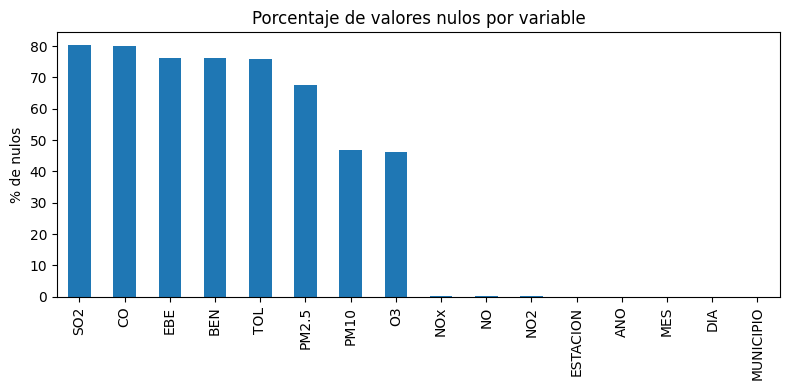

In [5]:
# Represento el porcentaje de nulos para ver mejor qué variables dan más problemas
plt.figure(figsize=(8,4))
resumen['%_nulos'].sort_values(ascending=False).plot(kind='bar')
plt.title('Porcentaje de valores nulos por variable')
plt.ylabel('% de nulos')
plt.tight_layout()
plt.show()

## Primera observación

Nada más revisar el dataset se ve que hay bastantes variables con muchos valores ausentes, por ejemplo `SO2`, `CO`, `TOL`, `BEN` o `EBE`. Para que la práctica quede más limpia me interesa trabajar con variables que tengan pocos nulos y que además estén relacionadas con la variable objetivo.


## Selección de estación y variable objetivo

He decidido trabajar primero con una sola estación para hacer el análisis más claro y después ampliar el estudio a varias estaciones. La estación elegida es la 24, porque tiene suficientes registros y varias variables útiles para el modelo.

Como variable objetivo voy a usar `NO2`. Como el problema tiene que ser de clasificación, convierto `NO2` en dos clases: `Baja` y `Alta`, usando la mediana como punto de corte.


In [6]:
# Compruebo cuántos registros tiene cada estación
conteo_estaciones = df['ESTACION'].value_counts().sort_index()
conteo_estaciones

ESTACION
4     266
8     330
11    333
16    334
17    334
18    334
24    317
27    334
35    334
36    334
38    332
39    334
40    334
47    333
48    334
49    334
50    334
54    334
55    329
56    334
57    334
58    334
59    334
60    334
Name: count, dtype: int64

In [7]:
# Me quedo solo con la estación 24 para el primer análisis
sub = df[df['ESTACION'] == 24].copy()
sub.isna().mean().sort_values() * 100

ANO            0.000000
MES            0.000000
DIA            0.000000
MUNICIPIO      0.000000
ESTACION       0.000000
NO             0.000000
PM2.5          0.000000
NO2            0.000000
O3             0.000000
NOx            0.000000
PM10           0.000000
BEN            1.892744
EBE            3.154574
TOL            4.416404
CO           100.000000
SO2          100.000000
dtype: float64

Se selecciona la **estación 24** porque:
1. tiene suficientes observaciones,
2. dispone de varias variables contaminantes útiles,
3. presenta pocos valores ausentes en las columnas más relevantes.

La variable objetivo será **`NO2`**, que se discretiza en dos clases usando la mediana de la estación 24.


In [8]:
# Discretizo NO2 usando la mediana de la estación 24
mediana_no2 = sub['NO2'].median()
sub['NO2_clase'] = np.where(sub['NO2'] <= mediana_no2, 'Baja', 'Alta')

print('Mediana de NO2 en estación 24:', mediana_no2)
sub['NO2_clase'].value_counts()

Mediana de NO2 en estación 24: 13.0


NO2_clase
Baja    161
Alta    156
Name: count, dtype: int64

## Distribución de la variable objetivo

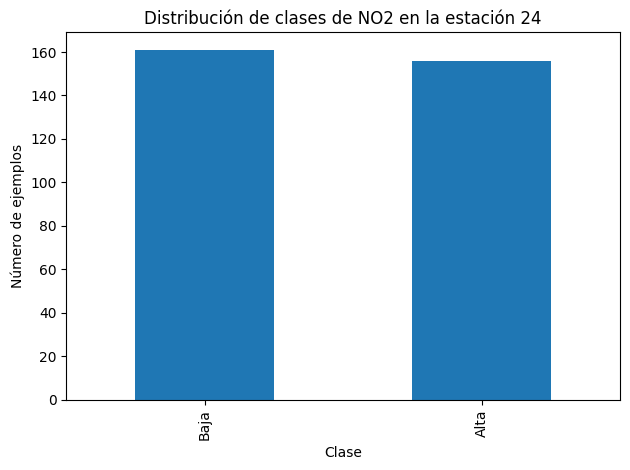

In [9]:
# Veo si las clases han quedado más o menos equilibradas
sub['NO2_clase'].value_counts().plot(kind='bar')
plt.title('Distribución de clases de NO2 en la estación 24')
plt.xlabel('Clase')
plt.ylabel('Número de ejemplos')
plt.tight_layout()
plt.show()

## Correlaciones y selección de atributos

En este punto calculo las correlaciones numéricas con `NO2` para quedarme con las variables más útiles. Además, el enunciado pide probar qué pasa al quitar la variable más correlacionada, así que esta parte es importante para justificar luego los experimentos.


In [10]:
# Calculo correlaciones respecto a NO2 para seleccionar predictores
candidate_vars = ['NOx','NO','BEN','PM2.5','TOL','PM10','O3','MES','DIA','NO2']
corr = sub[candidate_vars].corr(numeric_only=True)['NO2'].drop('NO2').sort_values(key=lambda s: s.abs(), ascending=False)
corr

NOx      0.975135
BEN      0.881822
NO       0.872071
PM2.5    0.728696
O3      -0.695361
TOL      0.508448
PM10     0.426054
MES     -0.037643
DIA      0.001429
Name: NO2, dtype: float64

## Visualización de la correlación

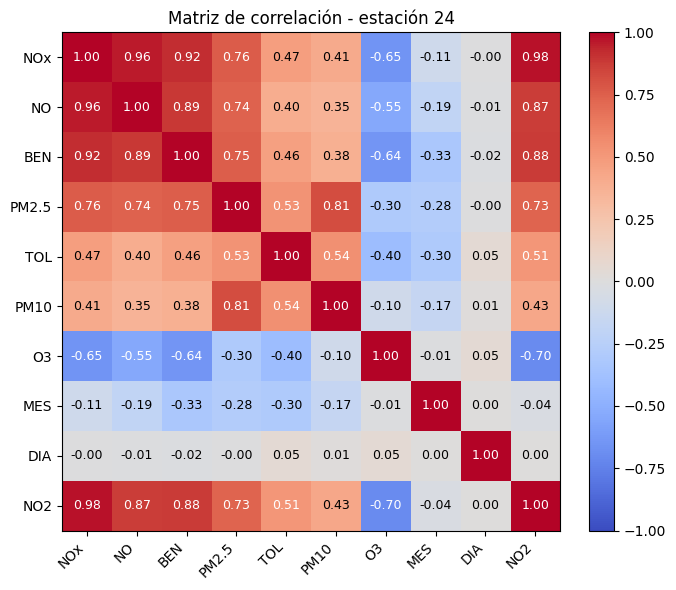

In [11]:
# Dibujo la matriz de correlación completa para tener una imagen más clara
corr_matrix = sub[candidate_vars].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        valor = corr_matrix.iloc[i, j]
        color = 'white' if abs(valor) > 0.5 else 'black'
        ax.text(j, i, f'{valor:.2f}', ha='center', va='center', color=color, fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.title('Matriz de correlación - estación 24')
plt.tight_layout()
plt.show()


## Interpretación de las correlaciones

La variable que más se relaciona con `NO2` es `NOx`, así que esa será la que quitaré después para comprobar cómo afecta al rendimiento. También se observa que `NO`, `BEN`, `PM2.5` y `O3` tienen relación con la variable objetivo, mientras que `MES` y `DIA` aportan menos, aunque las dejo para comprobar si recogen algún efecto temporal sencillo.


In [12]:
# Defino el conjunto completo y el conjunto sin NOx
features_all = ['NOx','NO','BEN','PM2.5','TOL','PM10','O3','MES','DIA']
features_no_nox = [f for f in features_all if f != 'NOx']

features_all, features_no_nox

(['NOx', 'NO', 'BEN', 'PM2.5', 'TOL', 'PM10', 'O3', 'MES', 'DIA'],
 ['NO', 'BEN', 'PM2.5', 'TOL', 'PM10', 'O3', 'MES', 'DIA'])

## Preparación de los datos y del modelo

En este caso no necesito discretizar los atributos predictivos porque `DecisionTreeClassifier` puede trabajar directamente con variables numéricas. Lo que sí hago es una imputación por mediana en las columnas que tienen algunos nulos, para no perder registros útiles y dejar el conjunto preparado antes de entrenar el árbol.


In [13]:
# Función para entrenar el árbol, ajustar parámetros y evaluar el resultado
def fit_tree(data, features, target='NO2_clase', random_state=42):
    X = data[features]
    y = data[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=random_state
    )

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', DecisionTreeClassifier(random_state=random_state, class_weight='balanced'))
    ])

    param_grid = {
        'clf__criterion': ['gini', 'entropy'],
        'clf__max_depth': [3, 4, 5, None],
        'clf__min_samples_split': [2, 10],
        'clf__min_samples_leaf': [1, 5],
        'clf__ccp_alpha': [0.0, 0.005]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    gs = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1_macro', n_jobs=1)
    gs.fit(X_train, y_train)

    best = gs.best_estimator_
    y_pred = best.predict(X_test)
    y_prob = best.predict_proba(X_test)[:, list(best.classes_).index('Alta')]

    resumen = {
        'mejores_parametros': gs.best_params_,
        'cv_f1_macro': gs.best_score_,
        'accuracy_test': accuracy_score(y_test, y_pred),
        'precision_macro_test': precision_score(y_test, y_pred, average='macro'),
        'recall_macro_test': recall_score(y_test, y_pred, average='macro'),
        'f1_macro_test': f1_score(y_test, y_pred, average='macro'),
        'auc_test': roc_auc_score((y_test == 'Alta').astype(int), y_prob),
        'matriz_confusion': confusion_matrix(y_test, y_pred, labels=['Baja','Alta'])
    }

    return best, resumen, X_train, X_test, y_train, y_test, y_pred, y_prob

## Experimento 1: árbol con todas las variables

Aquí entreno el modelo principal con todos los predictores seleccionados y hago ajuste de parámetros con validación cruzada.


In [14]:
# Entreno el modelo principal con todas las variables
model_all, res_all, X_train_all, X_test_all, y_train_all, y_test_all, y_pred_all, y_prob_all = fit_tree(sub, features_all)
res_all

{'mejores_parametros': {'clf__ccp_alpha': 0.0,
  'clf__criterion': 'gini',
  'clf__max_depth': 4,
  'clf__min_samples_leaf': 5,
  'clf__min_samples_split': 2},
 'cv_f1_macro': np.float64(0.9683535776660145),
 'accuracy_test': 0.9895833333333334,
 'precision_macro_test': 0.99,
 'recall_macro_test': 0.9893617021276595,
 'f1_macro_test': 0.9895731508634735,
 'auc_test': 0.9995657837603126,
 'matriz_confusion': array([[49,  0],
        [ 1, 46]])}

In [15]:
# Muestro informe de clasificación y matriz de confusión
print(classification_report(y_test_all, y_pred_all))
confusion_matrix(y_test_all, y_pred_all, labels=['Baja','Alta'])

              precision    recall  f1-score   support

        Alta       1.00      0.98      0.99        47
        Baja       0.98      1.00      0.99        49

    accuracy                           0.99        96
   macro avg       0.99      0.99      0.99        96
weighted avg       0.99      0.99      0.99        96



array([[49,  0],
       [ 1, 46]])

## Matriz de confusión del modelo principal

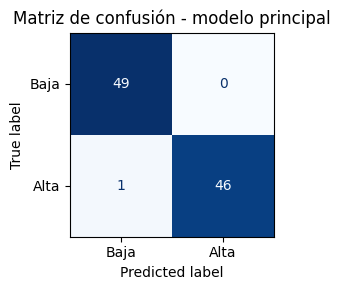

In [16]:
# Represento la matriz de confusión para verla mejor
cm_all = confusion_matrix(y_test_all, y_pred_all, labels=['Baja','Alta'])

fig, ax = plt.subplots(figsize=(4,3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_all, display_labels=['Baja','Alta'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión - modelo principal')
plt.tight_layout()
plt.show()


In [17]:
# Calculo la importancia de variables del árbol final
import pandas as pd
fi_all = pd.Series(model_all.named_steps['clf'].feature_importances_, index=features_all).sort_values(ascending=False)
fi_all

NOx      0.967308
NO       0.028901
MES      0.003791
PM2.5    0.000000
BEN      0.000000
TOL      0.000000
PM10     0.000000
O3       0.000000
DIA      0.000000
dtype: float64

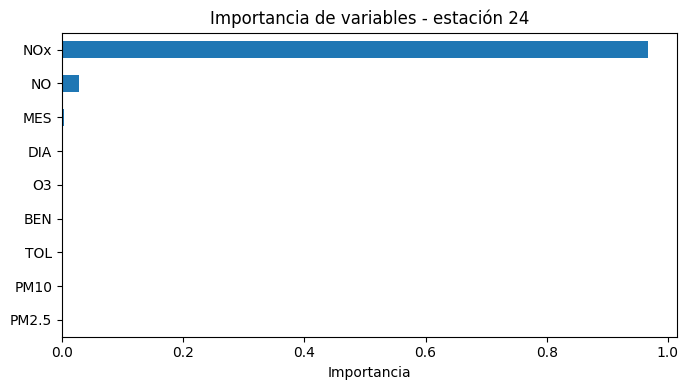

In [18]:
# Represento la importancia de cada predictor
plt.figure(figsize=(7,4))
fi_all.sort_values().plot(kind='barh')
plt.title('Importancia de variables - estación 24')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

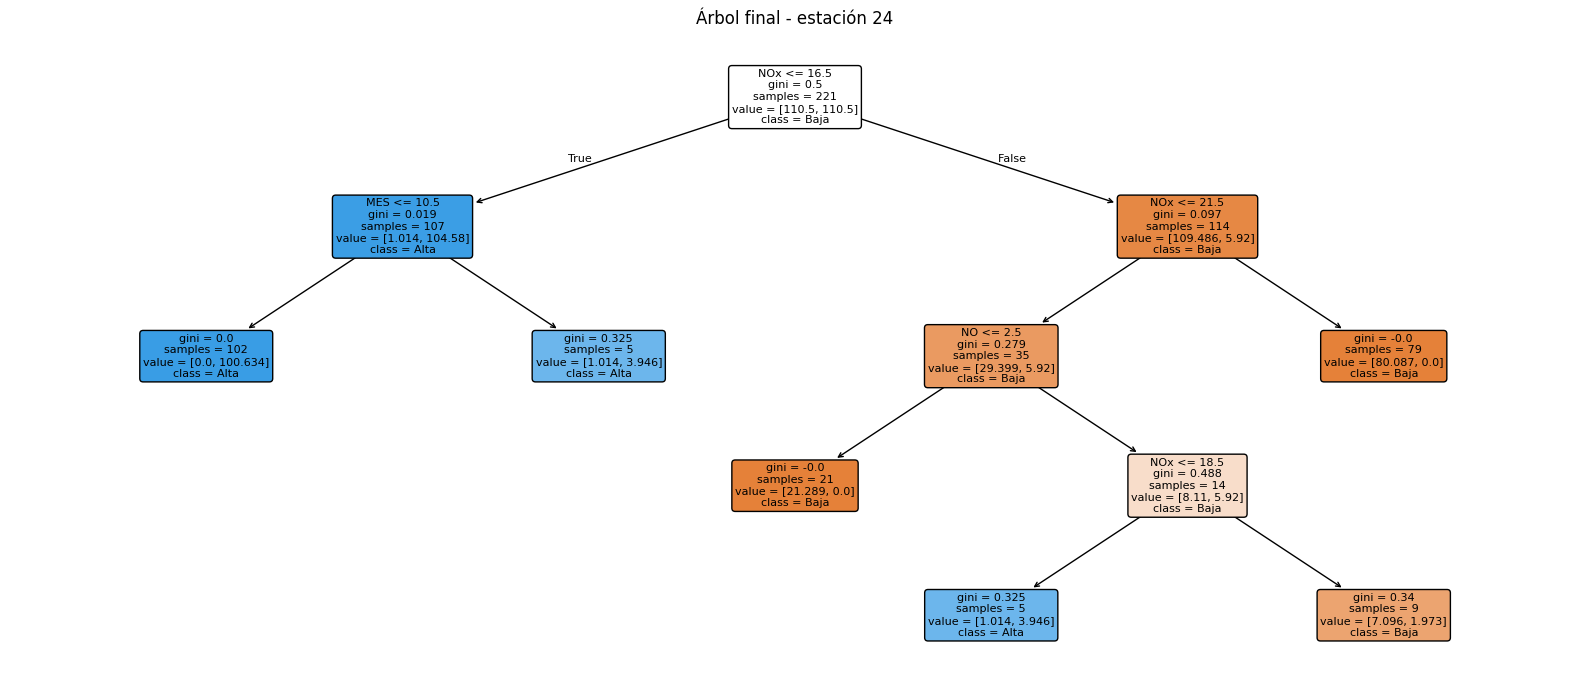

In [19]:
# Dibujo el árbol de decisión resultante
plt.figure(figsize=(16,7))
plot_tree(
    model_all.named_steps['clf'],
    feature_names=features_all,
    class_names=['Baja','Alta'],
    filled=True, rounded=True, fontsize=8
)
plt.title('Árbol final - estación 24')
plt.tight_layout()
plt.show()

## Experimento 2: quitando la variable más correlacionada

Ahora repito el mismo proceso pero eliminando `NOx`, que era la variable más correlacionada con `NO2`, para ver si realmente su ausencia empeora el modelo.


In [20]:
# Repito el experimento quitando NOx
model_no_nox, res_no_nox, X_train_nn, X_test_nn, y_train_nn, y_test_nn, y_pred_nn, y_prob_nn = fit_tree(sub, features_no_nox)
res_no_nox

{'mejores_parametros': {'clf__ccp_alpha': 0.0,
  'clf__criterion': 'entropy',
  'clf__max_depth': 3,
  'clf__min_samples_leaf': 5,
  'clf__min_samples_split': 2},
 'cv_f1_macro': np.float64(0.855160794715901),
 'accuracy_test': 0.84375,
 'precision_macro_test': 0.84375,
 'recall_macro_test': 0.8438992618323926,
 'f1_macro_test': 0.8437330439500814,
 'auc_test': 0.9177160225792445,
 'matriz_confusion': array([[41,  8],
        [ 7, 40]])}

In [21]:
# Vuelvo a revisar métricas y matriz de confusión
print(classification_report(y_test_nn, y_pred_nn))
confusion_matrix(y_test_nn, y_pred_nn, labels=['Baja','Alta'])

              precision    recall  f1-score   support

        Alta       0.83      0.85      0.84        47
        Baja       0.85      0.84      0.85        49

    accuracy                           0.84        96
   macro avg       0.84      0.84      0.84        96
weighted avg       0.84      0.84      0.84        96



array([[41,  8],
       [ 7, 40]])

## Matriz de confusión sin NOx

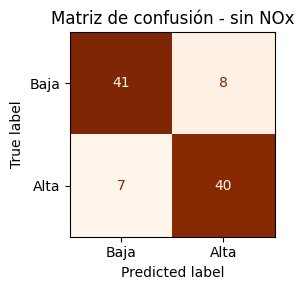

In [22]:
# Represento también la matriz de confusión del segundo experimento
cm_nn = confusion_matrix(y_test_nn, y_pred_nn, labels=['Baja','Alta'])

fig, ax = plt.subplots(figsize=(4,3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=['Baja','Alta'])
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Matriz de confusión - sin NOx')
plt.tight_layout()
plt.show()


## Comentario del experimento 2

Al quitar `NOx` el rendimiento baja. Esto era esperable, porque en la matriz de correlaciones ya se veía que era la variable con más relación respecto a `NO2`. Por tanto, esta prueba confirma que `NOx` tiene un peso importante dentro del árbol de decisión.


## Experimento 3: ampliación a varias estaciones

Para cubrir el criterio de ampliación del estudio, repito el análisis usando varias estaciones en lugar de una sola. De esta forma puedo comprobar si el árbol sigue funcionando bien cuando el problema es un poco más general.


In [23]:
# Amplío el estudio a varias estaciones
multi = df[df['ESTACION'].isin([8, 18, 24])].copy()
mediana_multi = multi['NO2'].median()
multi['NO2_clase'] = np.where(multi['NO2'] <= mediana_multi, 'Baja', 'Alta')

features_multi = ['ESTACION','NOx','NO','PM2.5','PM10','O3','BEN','TOL','MES','DIA']
model_multi, res_multi, X_train_m, X_test_m, y_train_m, y_test_m, y_pred_m, y_prob_m = fit_tree(multi, features_multi)
res_multi

{'mejores_parametros': {'clf__ccp_alpha': 0.0,
  'clf__criterion': 'entropy',
  'clf__max_depth': None,
  'clf__min_samples_leaf': 1,
  'clf__min_samples_split': 2},
 'cv_f1_macro': np.float64(0.9766462606449767),
 'accuracy_test': 0.9796610169491525,
 'precision_macro_test': 0.979642068457858,
 'recall_macro_test': 0.979642068457858,
 'f1_macro_test': 0.979642068457858,
 'auc_test': 0.979642068457858,
 'matriz_confusion': array([[149,   3],
        [  3, 140]])}

## Comentario de la ampliación

En este experimento añado también la variable `ESTACION` como predictor, porque así el árbol puede distinguir mejor entre ubicaciones distintas y aprovechar posibles diferencias entre estaciones.


In [24]:
# Comparo las métricas principales de los tres experimentos
comparacion = pd.DataFrame([
    {
        'Experimento': 'Estación 24 - todas las variables',
        'Accuracy': res_all['accuracy_test'],
        'F1 macro': res_all['f1_macro_test'],
        'AUC': res_all['auc_test']
    },
    {
        'Experimento': 'Estación 24 - sin NOx',
        'Accuracy': res_no_nox['accuracy_test'],
        'F1 macro': res_no_nox['f1_macro_test'],
        'AUC': res_no_nox['auc_test']
    },
    {
        'Experimento': 'Varias estaciones (8, 18 y 24)',
        'Accuracy': res_multi['accuracy_test'],
        'F1 macro': res_multi['f1_macro_test'],
        'AUC': res_multi['auc_test']
    }
])

comparacion

,Experimento,Accuracy,F1 macro,AUC
0,Estación 24 - todas las variables,0.989583,0.989573,0.999566
1,Estación 24 - sin NOx,0.843750,0.843733,0.917716
2,"Varias estaciones (8, 18 y 24)",0.979661,0.979642,0.979642


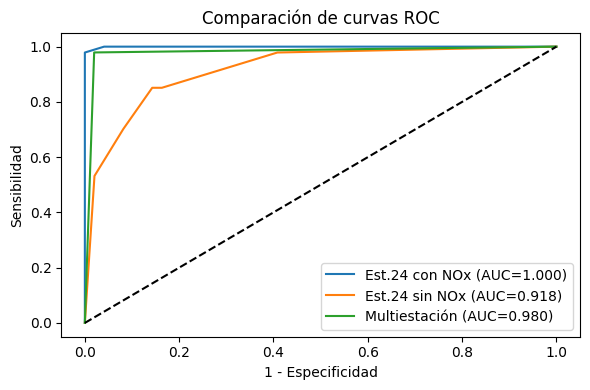

In [25]:
# Dibujo las curvas ROC para comparar mejor los modelos
plt.figure(figsize=(6,4))
for label, y_true, y_prob in [
    ('Est.24 con NOx', y_test_all, y_prob_all),
    ('Est.24 sin NOx', y_test_nn, y_prob_nn),
    ('Multiestación', y_test_m, y_prob_m)
]:
    y_bin = (y_true == 'Alta').astype(int)
    fpr, tpr, _ = roc_curve(y_bin, y_prob)
    auc = roc_auc_score(y_bin, y_prob)
    plt.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('1 - Especificidad')
plt.ylabel('Sensibilidad')
plt.title('Comparación de curvas ROC')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusiones

Después de hacer los tres experimentos, me quedo con varias ideas claras. La primera es que la estación 24 permite hacer un análisis bastante limpio, porque tiene suficientes datos y pocas ausencias en las variables principales. La segunda es que discretizar `NO2` con la mediana genera dos clases equilibradas, algo útil para la clasificación binaria.

Además, el árbol con todas las variables obtiene los mejores resultados. Cuando elimino `NOx`, el rendimiento baja, así que puedo concluir que era una variable muy importante para predecir la clase de `NO2`. Por último, al ampliar el estudio a varias estaciones el modelo sigue funcionando bien, lo que refuerza la idea de que el enfoque elegido es válido para esta práctica.
